<a href="https://colab.research.google.com/github/mountaindew93/2026-1_CV/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 동일 조건에서 재현 가능하게 하기 위해 시드 설정
np.random.seed(42)
tf.random.set_seed(42)

print("Import 및 환경 설정 완료")

Import 및 환경 설정 완료


In [5]:
# 1. 실험 A, C를 위한 Fashion-MNIST 데이터셋
(X_train_raw, y_train_raw), (X_val_raw, y_val_raw) = tf.keras.datasets.fashion_mnist.load_data()

# 28x28 이미지를 784차원 1D 벡터로 평탄화 및 0~1 정규화
X_train_f = X_train_raw.reshape(-1, 784) / 255.0
X_val_f = X_val_raw.reshape(-1, 784) / 255.0

# 다중 클래스 분류를 위한 One-hot Encoding
y_train_f = tf.one_hot(y_train_raw, 10)
y_val_f = tf.one_hot(y_val_raw, 10)

# tf.data 파이프라인 구성 (배치 크기 64)
ds_train_f = tf.data.Dataset.from_tensor_slices((X_train_f, y_train_f)).shuffle(10000).batch(64)
ds_val_f = tf.data.Dataset.from_tensor_slices((X_val_f, y_val_f)).batch(64)

# 2. 실험 B를 위한 make_moons 데이터셋 (비선형 분류, Dead ReLU 유도용)
X_m, y_m = make_moons(n_samples=1000, noise=0.15, random_state=42)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

y_train_m = tf.one_hot(y_train_m, 2)
y_val_m = tf.one_hot(y_val_m, 2)

ds_train_m = tf.data.Dataset.from_tensor_slices((X_train_m, y_train_m)).shuffle(1000).batch(64)
ds_val_m = tf.data.Dataset.from_tensor_slices((X_val_m, y_val_m)).batch(64)

print("데이터셋 로드 완료")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
데이터셋 로드 완료


In [6]:
# 실험 A, C 공통 MLP 아키텍처
def get_mnist_model():
    inputs = tf.keras.Input(shape=(784,))
    x1 = tf.keras.layers.Dense(256, activation='relu', name='fc1')(inputs)
    x2 = tf.keras.layers.Dense(128, activation='relu', name='fc2')(x1)
    outputs = tf.keras.layers.Dense(10, name='fc3')(x2)

    # 활성화 함수 분포(히스토그램) 시각화를 위해 중간 출력(x1, x2) 함께 반환
    return tf.keras.Model(inputs, [x1, x2, outputs])

# 실험 B 전용 아키텍처 (Dead ReLU 유도를 위한 극단적 초기화)
def get_activation_model(act_name):
    inputs = tf.keras.Input(shape=(2,))

    # Weight=0.01, Bias=-0.5 로 초기화하여 음수 입력을 유도
    w_init = tf.keras.initializers.RandomNormal(stddev=0.01)
    b_init = tf.keras.initializers.Constant(-0.5)

    x1 = tf.keras.layers.Dense(64, kernel_initializer=w_init, bias_initializer=b_init)(inputs)
    act1 = tf.keras.layers.LeakyReLU(0.01)(x1) if act_name == 'leaky_relu' else tf.keras.layers.Activation(act_name)(x1)

    x2 = tf.keras.layers.Dense(64, kernel_initializer=w_init, bias_initializer=b_init)(act1)
    act2 = tf.keras.layers.LeakyReLU(0.01)(x2) if act_name == 'leaky_relu' else tf.keras.layers.Activation(act_name)(x2)

    outputs = tf.keras.layers.Dense(2)(act2)
    return tf.keras.Model(inputs, [act1, act2, outputs])

print("모델 생성 완료")

모델 생성 완료


In [8]:
def run_exp_a(loss_type, epochs=30):
    print(f"\n--- 실험 A: {loss_type} 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_mnist_model()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True) if loss_type == 'Cross Entropy' else tf.keras.losses.MeanSquaredError()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'grad_init_fc1': None, 'grad_init_fc3': None,
               'grad_final_fc1': None, 'grad_final_fc3': None}

    total_batches = len(ds_train_f)

    for epoch in range(epochs):
        loss_metric = tf.keras.metrics.Mean(); acc_metric = tf.keras.metrics.CategoricalAccuracy()

        for batch_idx, (x, y) in enumerate(ds_train_f):
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                preds = tf.nn.softmax(logits)
                loss = loss_fn(y, logits) if loss_type == 'Cross Entropy' else loss_fn(y, preds)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            loss_metric.update_state(loss); acc_metric.update_state(y, preds)

            # 선배 과제 반영: 첫 배치와 마지막 배치의 기울기 분포 캡처 (fc1=grads[0], fc3=grads[-2])
            if epoch == 0 and batch_idx == 0:
                history['grad_init_fc1'] = grads[0].numpy()
                history['grad_init_fc3'] = grads[-2].numpy()
            if epoch == epochs - 1 and batch_idx == total_batches - 1:
                history['grad_final_fc1'] = grads[0].numpy()
                history['grad_final_fc3'] = grads[-2].numpy()

        val_acc_metric = tf.keras.metrics.CategoricalAccuracy()
        val_loss_metric = tf.keras.metrics.Mean()
        for x_val, y_val in ds_val_f:
            _, _, val_logits = model(x_val, training=False)
            val_preds = tf.nn.softmax(val_logits)
            val_loss = loss_fn(y_val, val_logits) if loss_type == 'Cross Entropy' else loss_fn(y_val, val_preds)
            val_loss_metric.update_state(val_loss); val_acc_metric.update_state(y_val, val_preds)

        history['train_loss'].append(loss_metric.result().numpy())
        history['train_acc'].append(acc_metric.result().numpy())
        history['val_loss'].append(val_loss_metric.result().numpy())
        history['val_acc'].append(val_acc_metric.result().numpy())

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]*100:.2f}%")

    return history

EPOCHS_A = 30
res_ce = run_exp_a('Cross Entropy', epochs=EPOCHS_A)
res_mse = run_exp_a('MSE', epochs=EPOCHS_A)


--- 실험 A: Cross Entropy 학습 시작 ---
Epoch 01/30 | Train Loss: 0.4845 | Val Acc: 84.81%
Epoch 02/30 | Train Loss: 0.3600 | Val Acc: 86.07%
Epoch 03/30 | Train Loss: 0.3254 | Val Acc: 86.87%
Epoch 04/30 | Train Loss: 0.3034 | Val Acc: 86.76%
Epoch 05/30 | Train Loss: 0.2834 | Val Acc: 86.51%
Epoch 06/30 | Train Loss: 0.2664 | Val Acc: 87.73%
Epoch 07/30 | Train Loss: 0.2568 | Val Acc: 88.35%
Epoch 08/30 | Train Loss: 0.2471 | Val Acc: 87.71%
Epoch 09/30 | Train Loss: 0.2336 | Val Acc: 88.47%
Epoch 10/30 | Train Loss: 0.2262 | Val Acc: 88.76%
Epoch 11/30 | Train Loss: 0.2166 | Val Acc: 88.75%
Epoch 12/30 | Train Loss: 0.2083 | Val Acc: 88.02%
Epoch 13/30 | Train Loss: 0.2000 | Val Acc: 88.88%
Epoch 14/30 | Train Loss: 0.1944 | Val Acc: 89.55%
Epoch 15/30 | Train Loss: 0.1859 | Val Acc: 89.17%
Epoch 16/30 | Train Loss: 0.1802 | Val Acc: 88.67%
Epoch 17/30 | Train Loss: 0.1737 | Val Acc: 89.42%
Epoch 18/30 | Train Loss: 0.1683 | Val Acc: 89.96%
Epoch 19/30 | Train Loss: 0.1620 | Val Acc: 89.

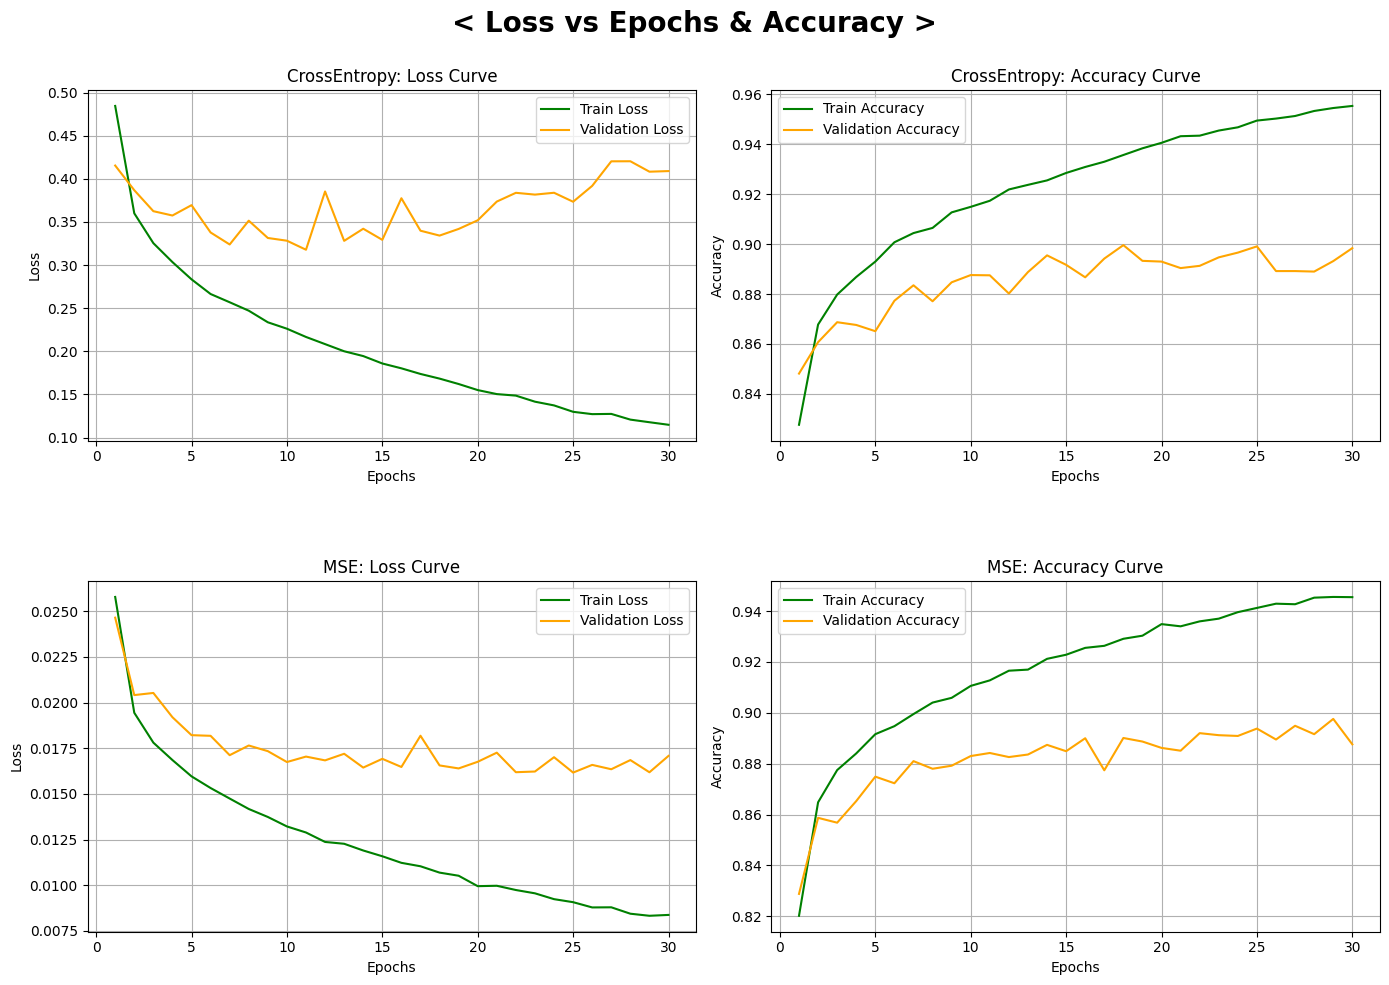

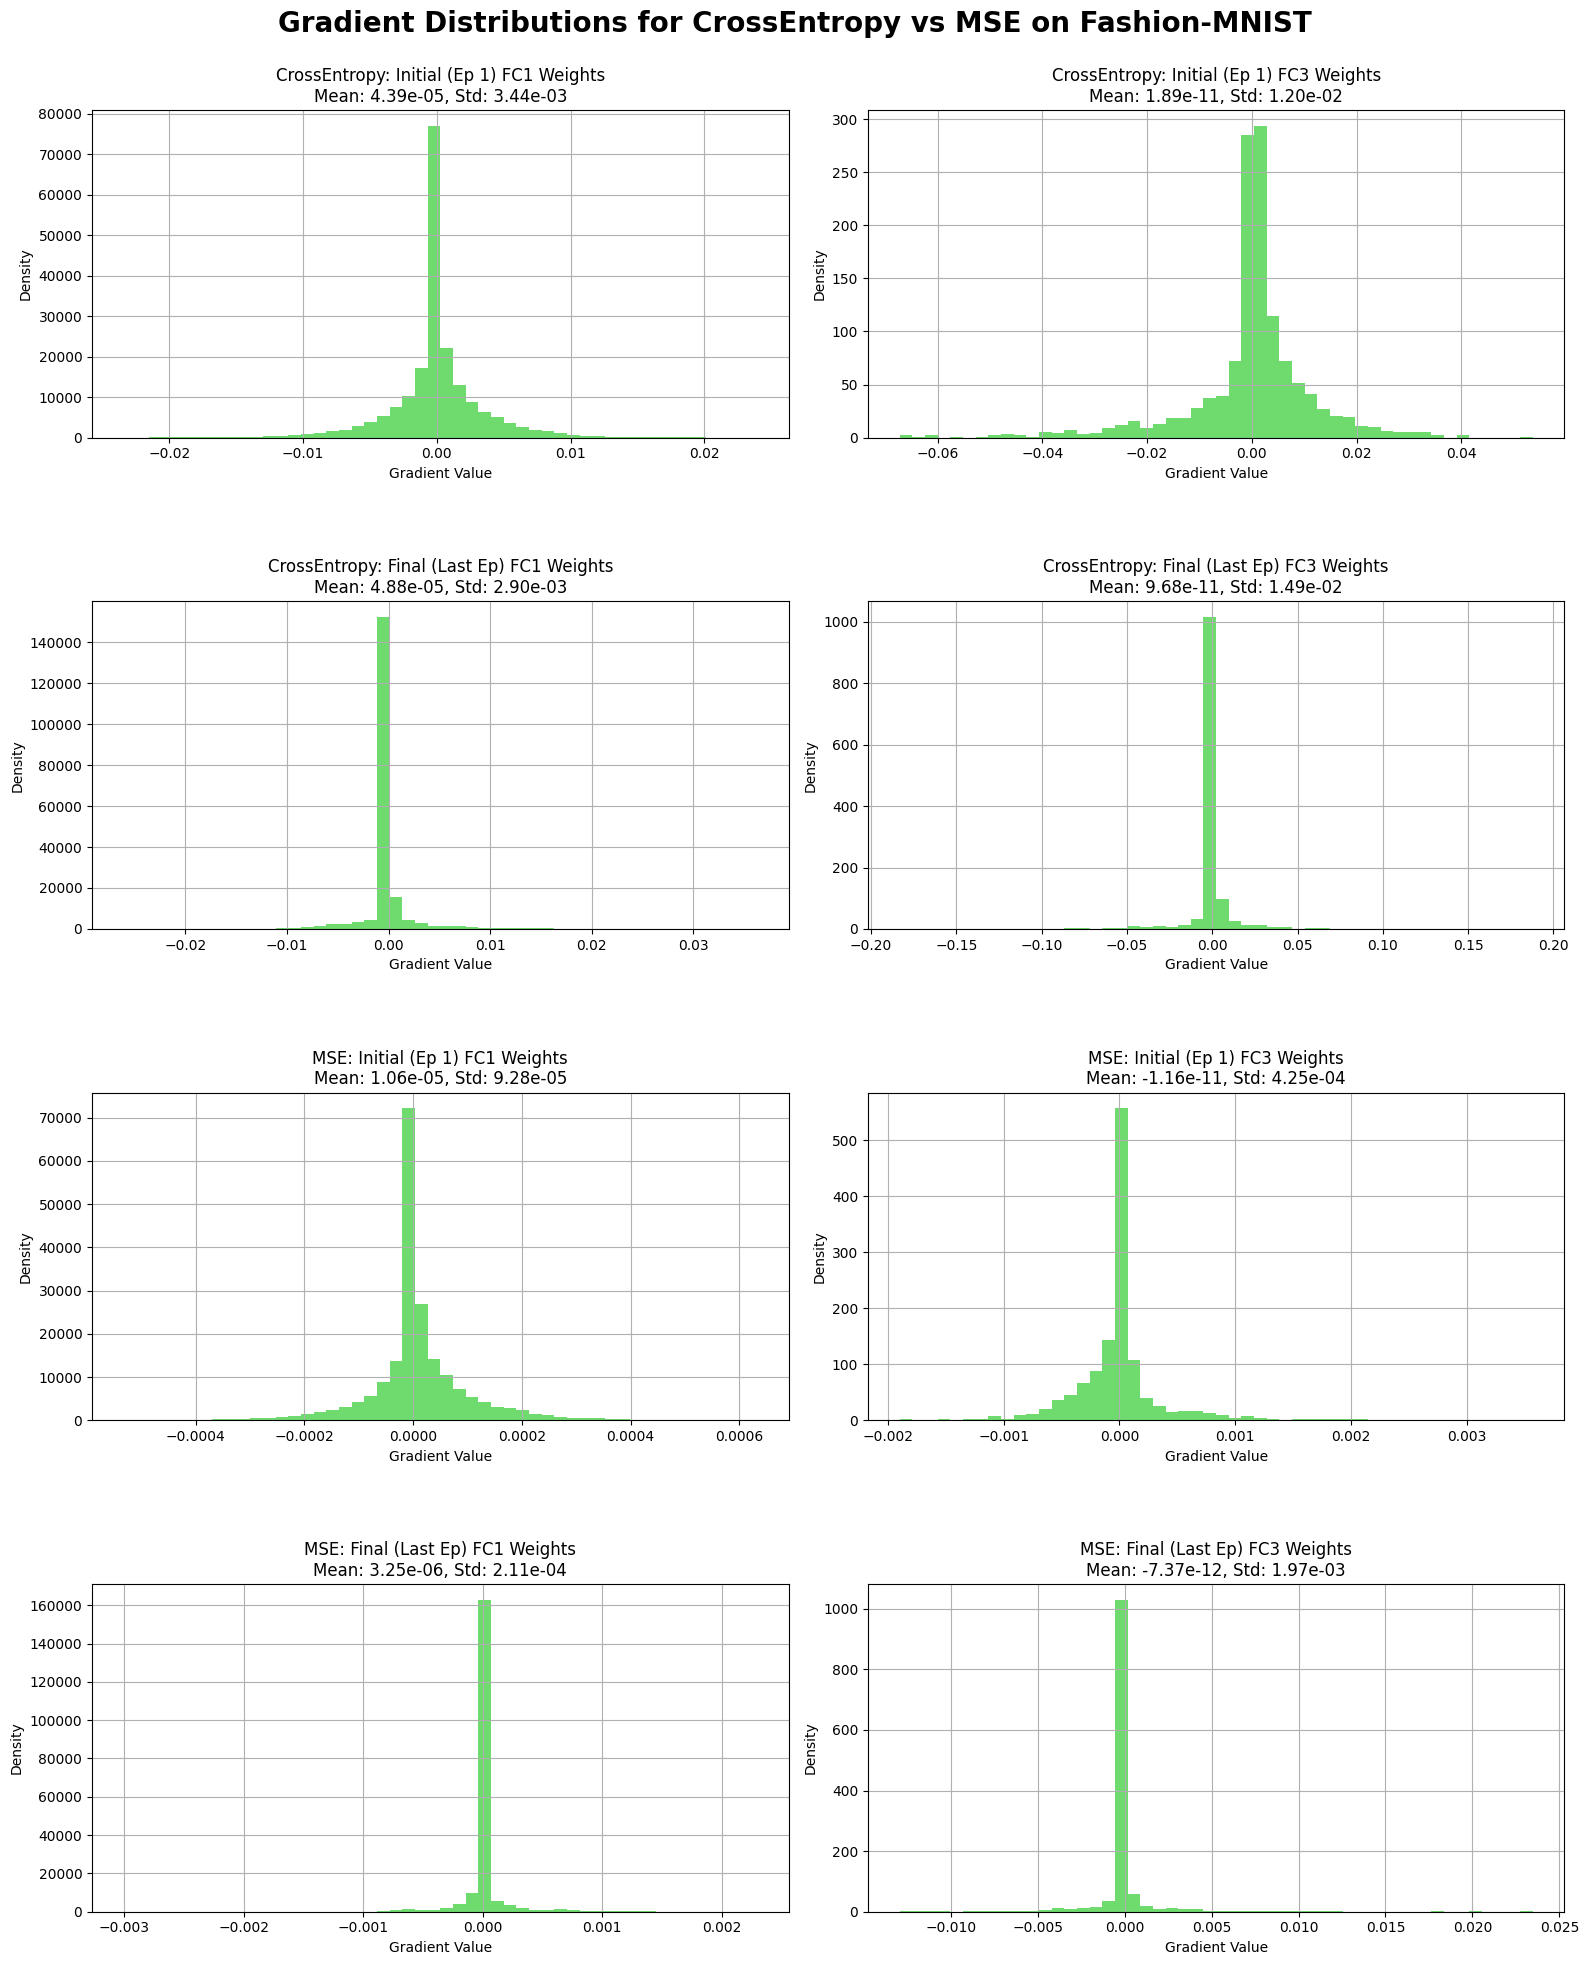

In [23]:
epochs_range = range(1, EPOCHS_A + 1)

# 1. Performance Metrics (Loss & Accuracy 비교)
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))

# [1행] CrossEntropy 영역
axes1[0, 0].plot(epochs_range, res_ce['train_loss'], label='Train Loss', color='g')
axes1[0, 0].plot(epochs_range, res_ce['val_loss'], label='Validation Loss', color='orange')
axes1[0, 0].set_title('CrossEntropy: Loss Curve')
axes1[0, 0].set_xlabel('Epochs'); axes1[0, 0].set_ylabel('Loss'); axes1[0, 0].legend(); axes1[0, 0].grid(True)

axes1[0, 1].plot(epochs_range, res_ce['train_acc'], label='Train Accuracy', color='g')
axes1[0, 1].plot(epochs_range, res_ce['val_acc'], label='Validation Accuracy', color='orange')
axes1[0, 1].set_title('CrossEntropy: Accuracy Curve')
axes1[0, 1].set_xlabel('Epochs'); axes1[0, 1].set_ylabel('Accuracy'); axes1[0, 1].legend(); axes1[0, 1].grid(True)

# [2행] MSE 영역
axes1[1, 0].plot(epochs_range, res_mse['train_loss'], label='Train Loss', color='g')
axes1[1, 0].plot(epochs_range, res_mse['val_loss'], label='Validation Loss', color='orange')
axes1[1, 0].set_title('MSE: Loss Curve')
axes1[1, 0].set_xlabel('Epochs'); axes1[1, 0].set_ylabel('Loss'); axes1[1, 0].legend(); axes1[1, 0].grid(True)

axes1[1, 1].plot(epochs_range, res_mse['train_acc'], label='Train Accuracy', color='g')
axes1[1, 1].plot(epochs_range, res_mse['val_acc'], label='Validation Accuracy', color='orange')
axes1[1, 1].set_title('MSE: Accuracy Curve')
axes1[1, 1].set_xlabel('Epochs'); axes1[1, 1].set_ylabel('Accuracy'); axes1[1, 1].legend(); axes1[1, 1].grid(True)

fig1.tight_layout()
fig1.subplots_adjust(top=0.9, hspace=0.4)
fig1.suptitle('< Loss vs Epochs & Accuracy >', fontsize=20, fontweight='bold')
plt.show()

# 2. Gradient Distributions (FC1 & FC3 히스토그램 대시보드)
def plot_grad_hist(ax, grad_data, title):
    ax.hist(grad_data.flatten(), bins=50, alpha=0.7, color='limegreen')
    # 평균(Mean)과 표준편차(Std)를 제목에 표기
    ax.set_title(f"{title}\nMean: {np.mean(grad_data):.2e}, Std: {np.std(grad_data):.2e}")
    ax.set_xlabel('Gradient Value')
    ax.set_ylabel('Density')
    ax.grid(True)

# 4행 2열 구조로 모든 경우의 수(CE/MSE x Initial/Final x FC1/FC3) 시각화
fig2, axes2 = plt.subplots(4, 2, figsize=(16, 20))

# [1~2행] CrossEntropy 그래디언트
plot_grad_hist(axes2[0, 0], res_ce['grad_init_fc1'], "CrossEntropy: Initial (Ep 1) FC1 Weights")
plot_grad_hist(axes2[0, 1], res_ce['grad_init_fc3'], "CrossEntropy: Initial (Ep 1) FC3 Weights")
plot_grad_hist(axes2[1, 0], res_ce['grad_final_fc1'], "CrossEntropy: Final (Last Ep) FC1 Weights")
plot_grad_hist(axes2[1, 1], res_ce['grad_final_fc3'], "CrossEntropy: Final (Last Ep) FC3 Weights")

# [3~4행] MSE 그래디언트 (Vanishing Gradient 관찰용)
plot_grad_hist(axes2[2, 0], res_mse['grad_init_fc1'], "MSE: Initial (Ep 1) FC1 Weights")
plot_grad_hist(axes2[2, 1], res_mse['grad_init_fc3'], "MSE: Initial (Ep 1) FC3 Weights")
plot_grad_hist(axes2[3, 0], res_mse['grad_final_fc1'], "MSE: Final (Last Ep) FC1 Weights")
plot_grad_hist(axes2[3, 1], res_mse['grad_final_fc3'], "MSE: Final (Last Ep) FC3 Weights")

fig2.tight_layout()
fig2.subplots_adjust(top=0.93, hspace=0.5)
fig2.suptitle('Gradient Distributions for CrossEntropy vs MSE on Fashion-MNIST', fontsize=20, fontweight='bold')
plt.show()

In [7]:
def run_exp_b(act_name, epochs=150):
    print(f"\n--- 실험 B: {act_name} 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_activation_model(act_name)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'grad_mean': [], 'act_early': None, 'act_mid': None, 'act_late': None}

    for epoch in range(epochs):
        t_loss = tf.keras.metrics.Mean(); t_acc = tf.keras.metrics.CategoricalAccuracy()
        grads_epoch = []

        for x, y in ds_train_m:
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                loss = loss_fn(y, logits)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            grads_epoch.append(tf.reduce_mean(tf.abs(grads[0])).numpy()) # Layer 1 Gradient
            t_loss.update_state(loss); t_acc.update_state(y, tf.nn.softmax(logits))

        v_loss = tf.keras.metrics.Mean(); v_acc = tf.keras.metrics.CategoricalAccuracy()
        for x_val, y_val in ds_val_m:
            _, _, val_logits = model(x_val, training=False)
            v_loss.update_state(loss_fn(y_val, val_logits))
            v_acc.update_state(y_val, tf.nn.softmax(val_logits))

        history['train_loss'].append(t_loss.result().numpy())
        history['train_acc'].append(t_acc.result().numpy())
        history['val_loss'].append(v_loss.result().numpy())
        history['val_acc'].append(v_acc.result().numpy())
        history['grad_mean'].append(np.mean(grads_epoch))

        # 활성화 함수 분포 캡처
        if epoch == 0: history['act_early'] = model(X_val_m, training=False)[0].numpy()
        elif epoch == epochs // 2: history['act_mid'] = model(X_val_m, training=False)[0].numpy()
        elif epoch == epochs - 1: history['act_late'] = model(X_val_m, training=False)[0].numpy()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Val Acc: {history['val_acc'][-1]*100:.2f}% | L1 Grad: {history['grad_mean'][-1]:.6f}")

    # 결정 경계 시각화를 위한 2D Grid 데이터 예측
    xx, yy = np.meshgrid(np.linspace(-2.5, 3.5, 100), np.linspace(-2.0, 2.5, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, _, grid_logits = model(grid, training=False)
    history['decision_z'] = tf.argmax(tf.nn.softmax(grid_logits), axis=1).numpy().reshape(xx.shape)
    history['xx'] = xx; history['yy'] = yy

    # 히트맵용 최종 출력
    act1_out, _, _ = model(X_val_m, training=False)
    history['final_act1'] = act1_out.numpy()

    return history

EPOCHS_B = 150
res_relu = run_exp_b('relu', epochs=EPOCHS_B)
res_leaky = run_exp_b('leaky_relu', epochs=EPOCHS_B)
res_sig = run_exp_b('sigmoid', epochs=EPOCHS_B)


--- 실험 B: relu 학습 시작 ---
Epoch 001/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 010/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 020/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 030/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 040/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 050/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 060/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 070/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 080/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 090/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 100/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 110/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 120/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 130/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 140/150 | Val Acc: 50.00% | L1 Grad: 0.000000
Epoch 150/150 | Val Acc: 50.00% | L1 Grad: 0.000000

--- 실험 B: leaky_relu 학습 시작 ---
Epoch 001/150 | Val Acc: 50.00% | L1 Grad: 0.000001
Epoch 010/150 | Val Acc: 98.50% | L1 Grad: 0.003712
Epoch 

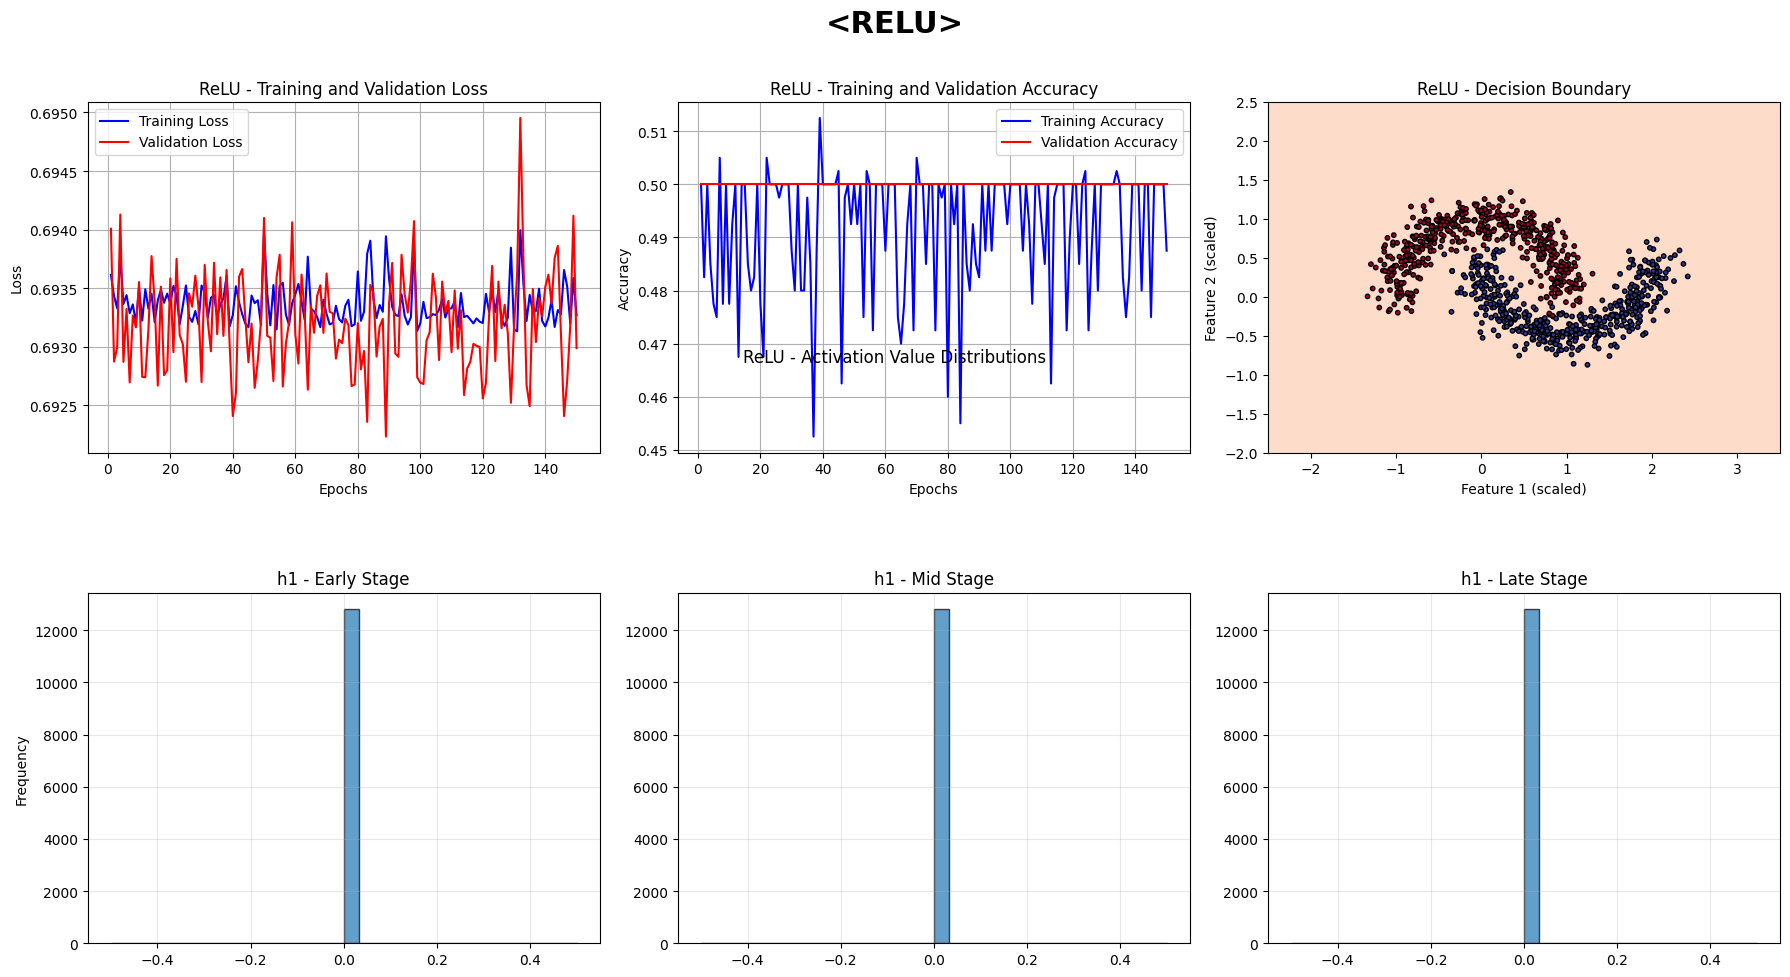

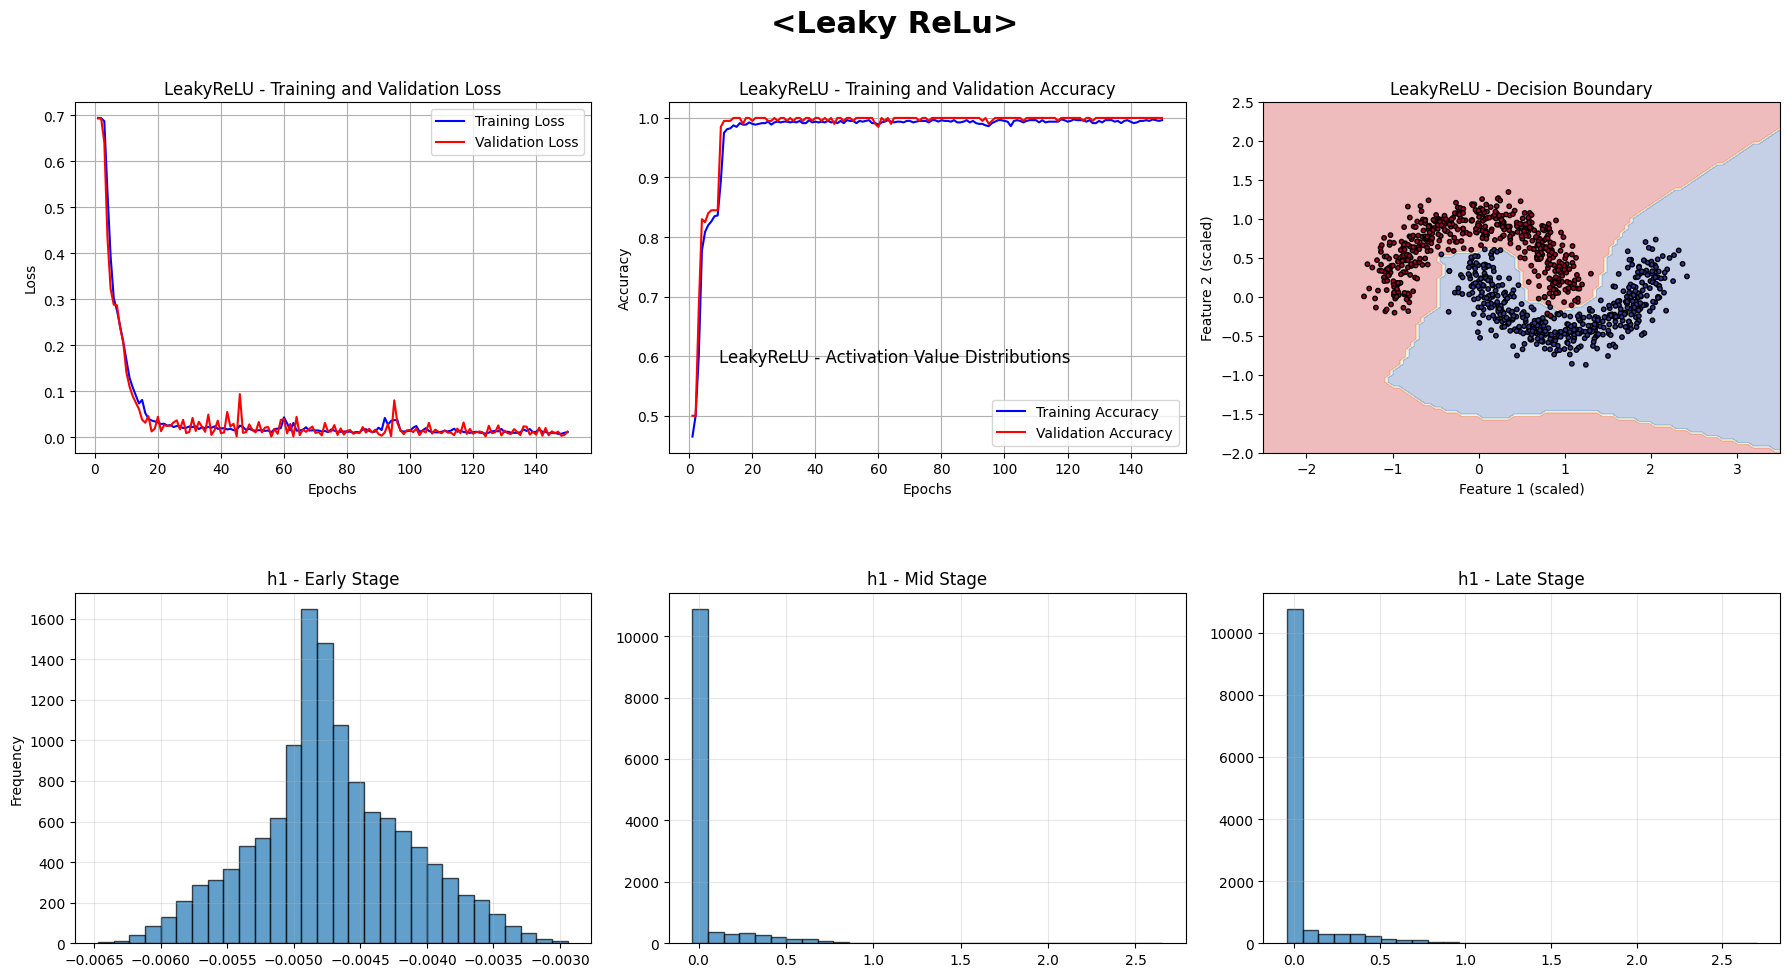

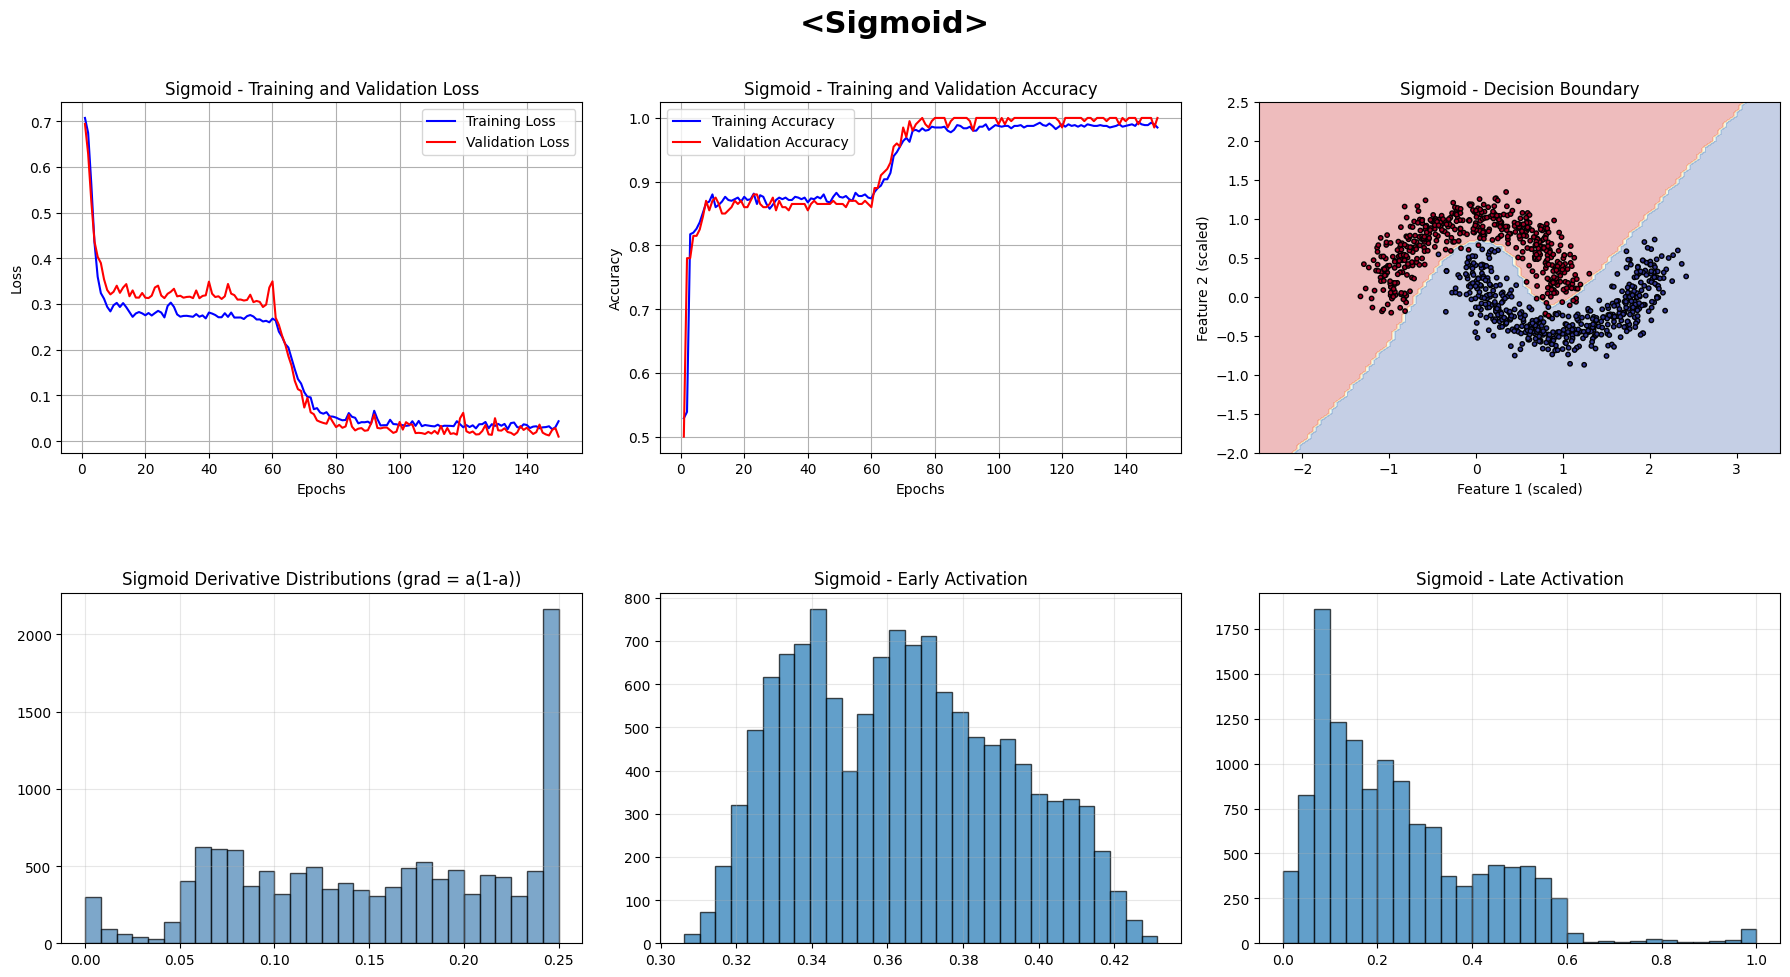

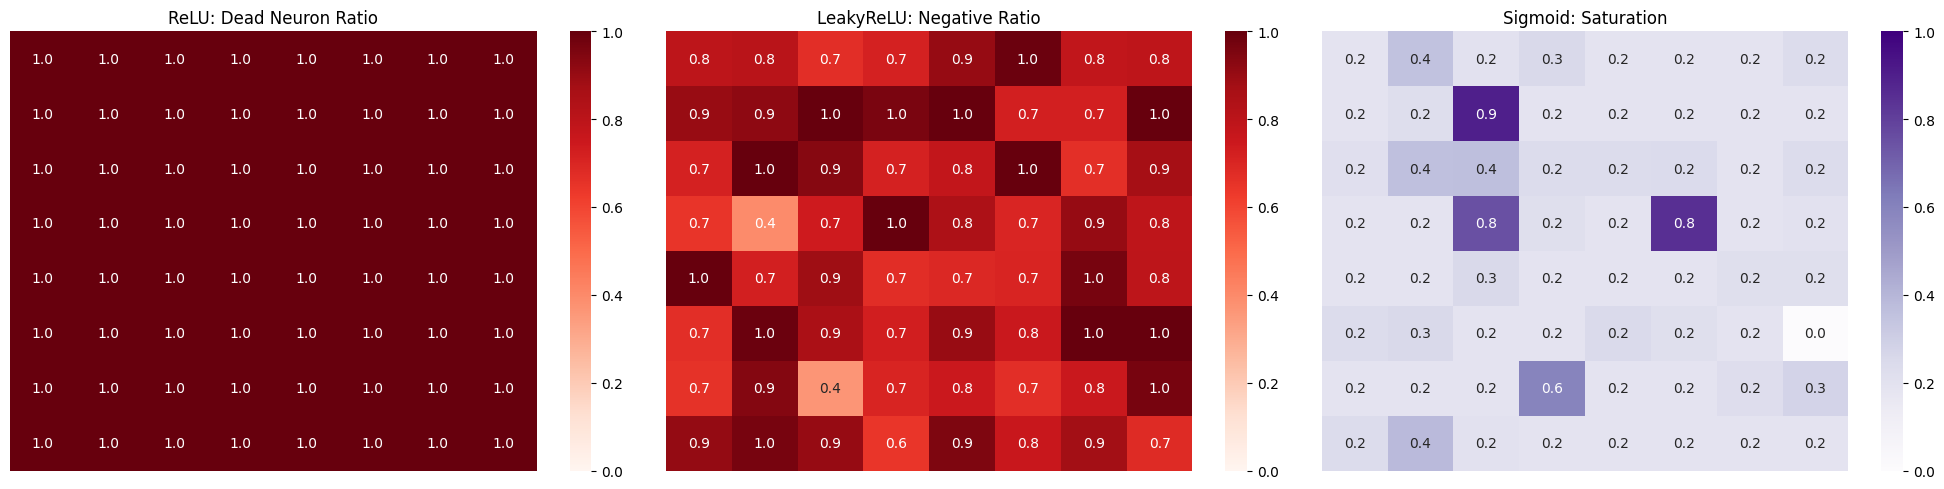

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12685 (\N{HANGUL LETTER ARAEA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


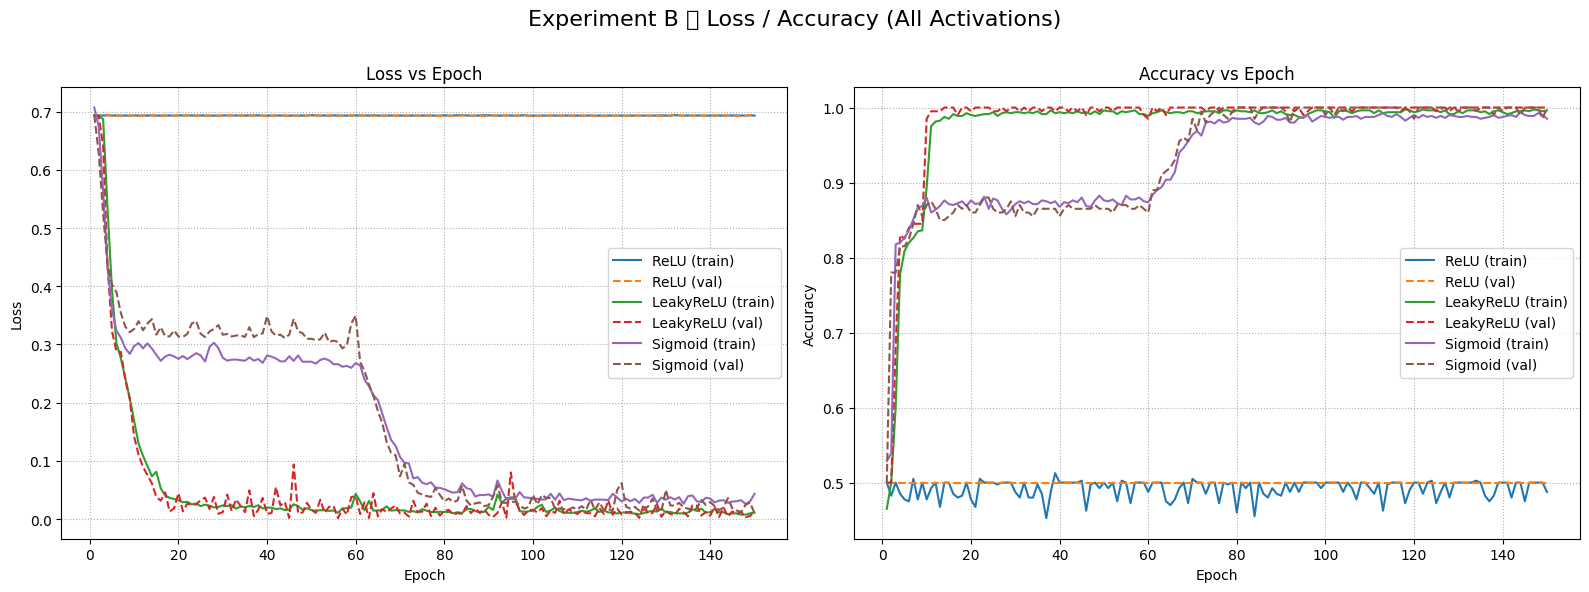

In [9]:
e_range = range(1, EPOCHS_B + 1)

# 1) <ReLU>
fig_relu = plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.plot(e_range, res_relu['train_loss'], 'b-', label='Training Loss') # 'b-o'에서 점 제거
plt.plot(e_range, res_relu['val_loss'], 'r-', label='Validation Loss') # 'r-o'에서 점 제거
plt.title('ReLU - Training and Validation Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(e_range, res_relu['train_acc'], 'b-', label='Training Accuracy') # 'b-o'에서 점 제거
plt.plot(e_range, res_relu['val_acc'], 'r-', label='Validation Accuracy') # 'r-o'에서 점 제거
plt.title('ReLU - Training and Validation Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 3)
plt.contourf(res_relu['xx'], res_relu['yy'], res_relu['decision_z'], alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=10, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title('ReLU - Decision Boundary'); plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)')

plt.subplot(2, 3, 4)
plt.hist(res_relu['act_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Early Stage'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.hist(res_relu['act_mid'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Mid Stage'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
plt.hist(res_relu['act_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Late Stage'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.4)
fig_relu.text(0.5, 0.95, '<RELU>', ha='center', fontsize=22, fontweight='bold')
fig_relu.text(0.5, 0.62, 'ReLU - Activation Value Distributions', ha='center', fontsize=12)
plt.show()


# 2) <LeakyReLU>
fig_leaky = plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.plot(e_range, res_leaky['train_loss'], 'b-', label='Training Loss')
plt.plot(e_range, res_leaky['val_loss'], 'r-', label='Validation Loss')
plt.title('LeakyReLU - Training and Validation Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(e_range, res_leaky['train_acc'], 'b-', label='Training Accuracy')
plt.plot(e_range, res_leaky['val_acc'], 'r-', label='Validation Accuracy')
plt.title('LeakyReLU - Training and Validation Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 3)
plt.contourf(res_leaky['xx'], res_leaky['yy'], res_leaky['decision_z'], alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=10, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title('LeakyReLU - Decision Boundary'); plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)')

plt.subplot(2, 3, 4)
plt.hist(res_leaky['act_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Early Stage'); plt.ylabel('Frequency'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.hist(res_leaky['act_mid'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Mid Stage'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
plt.hist(res_leaky['act_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('h1 - Late Stage'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.4)
fig_leaky.text(0.5, 0.95, '<Leaky ReLu>', ha='center', fontsize=22, fontweight='bold')
fig_leaky.text(0.5, 0.62, 'LeakyReLU - Activation Value Distributions', ha='center', fontsize=12)
plt.show()


# 3) <Sigmoid> 독립 대시보드
fig_sig = plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.plot(e_range, res_sig['train_loss'], 'b-', label='Training Loss')
plt.plot(e_range, res_sig['val_loss'], 'r-', label='Validation Loss')
plt.title('Sigmoid - Training and Validation Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(e_range, res_sig['train_acc'], 'b-', label='Training Accuracy')
plt.plot(e_range, res_sig['val_acc'], 'r-', label='Validation Accuracy')
plt.title('Sigmoid - Training and Validation Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(2, 3, 3)
plt.contourf(res_sig['xx'], res_sig['yy'], res_sig['decision_z'], alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=10, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title('Sigmoid - Decision Boundary'); plt.xlabel('Feature 1 (scaled)'); plt.ylabel('Feature 2 (scaled)')

sig_act = res_sig['final_act1']
sig_deriv = sig_act * (1.0 - sig_act)

plt.subplot(2, 3, 4)
plt.hist(sig_deriv.flatten(), bins=30, alpha=0.7, edgecolor='k', color='steelblue')
plt.title('Sigmoid Derivative Distributions (grad = a(1-a))'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.hist(res_sig['act_early'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('Sigmoid - Early Activation'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
plt.hist(res_sig['act_late'].flatten(), bins=30, alpha=0.7, edgecolor='k')
plt.title('Sigmoid - Late Activation'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.4)
fig_sig.text(0.5, 0.95, '<Sigmoid>', ha='center', fontsize=22, fontweight='bold')
plt.show()


# =====================================================================
# 4) 뉴런 활성화 상태 히트맵 가로 배치 (기존 동일)
# =====================================================================
fig_heat, axes_heat = plt.subplots(1, 3, figsize=(20, 5))

def plot_dead_heatmap_clean(act_data, ax, title, is_sigmoid=False):
    ratio = np.mean((act_data <= 0.1) | (act_data >= 0.9), axis=0) if is_sigmoid else np.mean(act_data <= 0.0, axis=0)
    sns.heatmap(ratio.reshape(8, 8), annot=True, fmt=".1f", cmap="Purples" if is_sigmoid else "Reds", ax=ax, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plot_dead_heatmap_clean(res_relu['final_act1'], axes_heat[0], 'ReLU: Dead Neuron Ratio')
plot_dead_heatmap_clean(res_leaky['final_act1'], axes_heat[1], 'LeakyReLU: Negative Ratio')
plot_dead_heatmap_clean(res_sig['final_act1'], axes_heat[2], 'Sigmoid: Saturation', is_sigmoid=True)

plt.tight_layout()
plt.show()


# =====================================================================
# 5) Experiment B 통합 비교 곡선 (기존 동일 - 이미 마커 점이 없는 형태)
# =====================================================================
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(16, 6))

# Loss 비교
axes_comp[0].plot(e_range, res_relu['train_loss'], label='ReLU (train)', color='C0')
axes_comp[0].plot(e_range, res_relu['val_loss'], label='ReLU (val)', color='C1', linestyle='--')
axes_comp[0].plot(e_range, res_leaky['train_loss'], label='LeakyReLU (train)', color='C2')
axes_comp[0].plot(e_range, res_leaky['val_loss'], label='LeakyReLU (val)', color='C3', linestyle='--')
axes_comp[0].plot(e_range, res_sig['train_loss'], label='Sigmoid (train)', color='C4')
axes_comp[0].plot(e_range, res_sig['val_loss'], label='Sigmoid (val)', color='C5', linestyle='--')
axes_comp[0].set_title('Loss vs Epoch'); axes_comp[0].set_xlabel('Epoch'); axes_comp[0].set_ylabel('Loss')
axes_comp[0].legend(); axes_comp[0].grid(True, linestyle=':')

# Accuracy 비교
axes_comp[1].plot(e_range, res_relu['train_acc'], label='ReLU (train)', color='C0')
axes_comp[1].plot(e_range, res_relu['val_acc'], label='ReLU (val)', color='C1', linestyle='--')
axes_comp[1].plot(e_range, res_leaky['train_acc'], label='LeakyReLU (train)', color='C2')
axes_comp[1].plot(e_range, res_leaky['val_acc'], label='LeakyReLU (val)', color='C3', linestyle='--')
axes_comp[1].plot(e_range, res_sig['train_acc'], label='Sigmoid (train)', color='C4')
axes_comp[1].plot(e_range, res_sig['val_acc'], label='Sigmoid (val)', color='C5', linestyle='--')
axes_comp[1].set_title('Accuracy vs Epoch'); axes_comp[1].set_xlabel('Epoch'); axes_comp[1].set_ylabel('Accuracy')
axes_comp[1].legend(); axes_comp[1].grid(True, linestyle=':')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
fig_comp.suptitle('Experiment B ㆍ Loss / Accuracy (All Activations)', fontsize=16)
plt.show()

In [ ]:
def run_exp_c(opt_name, lr_init, epochs=30):
    print(f"\n--- 실험 C: {opt_name} (LR: {lr_init}) 학습 시작 ---")
    tf.random.set_seed(42)
    model = get_mnist_model()

    steps_per_epoch = len(ds_train_f)
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr_init, decay_steps=steps_per_epoch, decay_rate=0.9, staircase=True
    )

    if opt_name == 'SGD': optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    elif opt_name == 'Momentum': optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
    else: optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    history = {'val_loss': [], 'val_acc': [], 'grad_mean': [], 'lr_curve': []}

    for epoch in range(epochs):
        v_loss = tf.keras.metrics.Mean(); v_acc = tf.keras.metrics.CategoricalAccuracy()
        grads_epoch = []

        for x, y in ds_train_f:
            with tf.GradientTape() as tape:
                _, _, logits = model(x, training=True)
                loss = loss_fn(y, logits)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            grads_epoch.append(tf.reduce_mean(tf.abs(grads[-2])).numpy())

        for x_val, y_val in ds_val_f:
            _, _, val_logits = model(x_val, training=False)
            v_loss.update_state(loss_fn(y_val, val_logits))
            v_acc.update_state(y_val, tf.nn.softmax(val_logits))

        history['val_loss'].append(v_loss.result().numpy())
        history['val_acc'].append(v_acc.result().numpy())
        history['grad_mean'].append(np.mean(grads_epoch))

        if callable(optimizer.learning_rate):
            current_lr = optimizer.learning_rate(optimizer.iterations).numpy()
        else:
            current_lr = optimizer.learning_rate.numpy()

        history['lr_curve'].append(current_lr)

        print(f"Epoch {epoch+1:02d}/{epochs} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]*100:.2f}% | LR: {current_lr:.6f}")

    # 히스토그램 분석을 위한 Layer 1의 최종 활성화 값 추출
    act1_out, _, _ = model(X_val_f, training=False)
    history['final_act1'] = act1_out.numpy()

    return history

EPOCHS_C = 30
opts = ['SGD', 'Momentum', 'Adam']
lrs = [0.1, 0.01, 0.001]
res_opt = {opt: {} for opt in opts}

for opt in opts:
    for lr in lrs:
        res_opt[opt][lr] = run_exp_c(opt, lr, epochs=EPOCHS_C)


--- 실험 C: SGD (LR: 0.1) 학습 시작 ---
Epoch 01/30 | Val Loss: 0.5866 | Val Acc: 78.47% | LR: 0.090000
Epoch 02/30 | Val Loss: 0.4083 | Val Acc: 85.03% | LR: 0.081000
Epoch 03/30 | Val Loss: 0.3966 | Val Acc: 85.79% | LR: 0.072900
Epoch 04/30 | Val Loss: 0.3924 | Val Acc: 86.09% | LR: 0.065610
Epoch 05/30 | Val Loss: 0.3552 | Val Acc: 87.20% | LR: 0.059049
Epoch 06/30 | Val Loss: 0.3539 | Val Acc: 87.24% | LR: 0.053144
Epoch 07/30 | Val Loss: 0.3349 | Val Acc: 87.75% | LR: 0.047830
Epoch 08/30 | Val Loss: 0.3644 | Val Acc: 86.56% | LR: 0.043047
Epoch 09/30 | Val Loss: 0.3283 | Val Acc: 87.72% | LR: 0.038742
Epoch 10/30 | Val Loss: 0.3399 | Val Acc: 87.80% | LR: 0.034868
Epoch 11/30 | Val Loss: 0.3396 | Val Acc: 87.75% | LR: 0.031381
Epoch 12/30 | Val Loss: 0.3191 | Val Acc: 88.72% | LR: 0.028243
Epoch 13/30 | Val Loss: 0.3343 | Val Acc: 87.63% | LR: 0.025419
Epoch 14/30 | Val Loss: 0.3158 | Val Acc: 88.81% | LR: 0.022877
Epoch 15/30 | Val Loss: 0.3208 | Val Acc: 88.63% | LR: 0.020589
Epoch

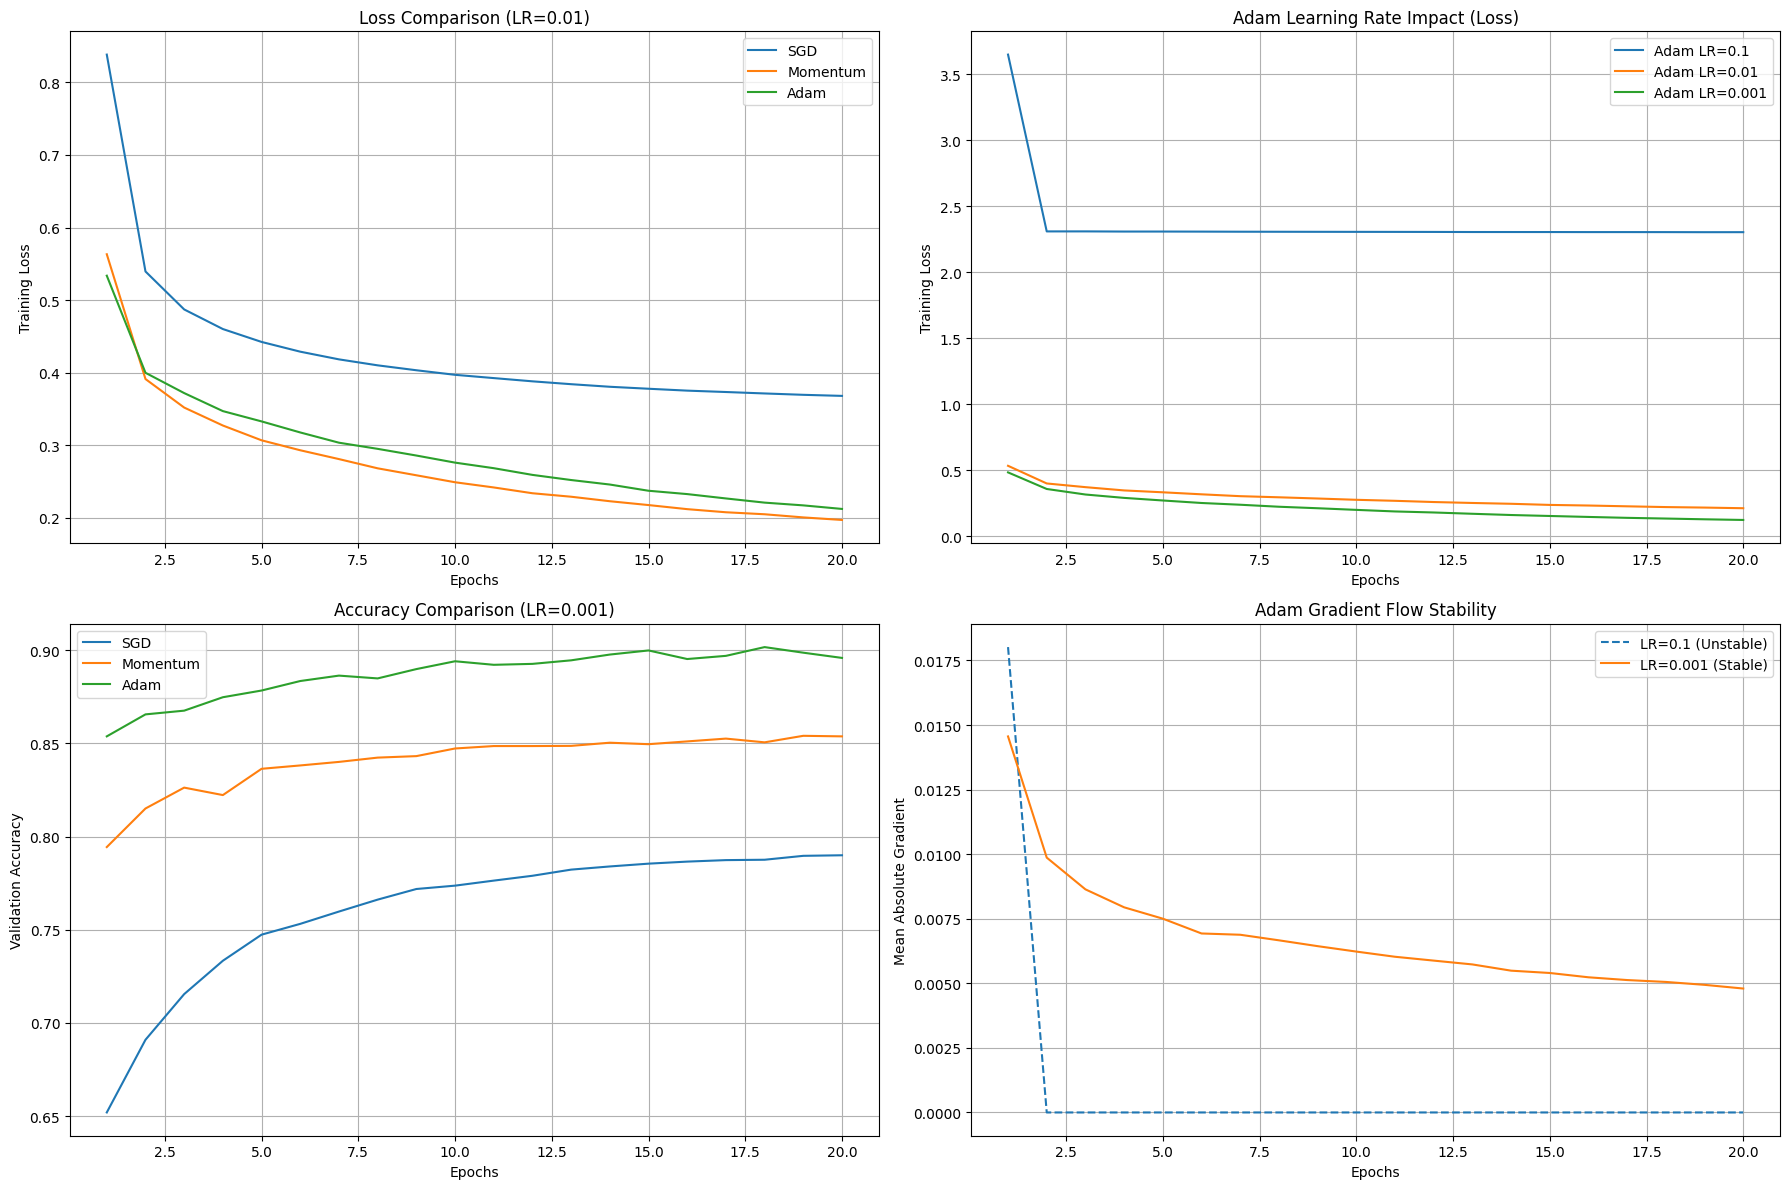

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
e_range = range(1, EPOCHS_C + 1)

# Adam 성능 시각화 대시보드 (선배 레퍼런스 완벽 구현)
# 1. Validation Loss
for lr, color in zip([0.1, 0.01, 0.001], ['blue', 'deepskyblue', 'navy']):
    axes[0, 0].plot(e_range, res_opt['Adam'][lr]['val_loss'], label=f'LR={lr}')
axes[0, 0].set_title('Adam: Validation Loss vs Epoch'); axes[0, 0].legend(); axes[0, 0].grid(True)

# 2. Validation Accuracy
for lr, color in zip([0.1, 0.01, 0.001], ['blue', 'deepskyblue', 'navy']):
    axes[1, 0].plot(e_range, res_opt['Adam'][lr]['val_acc'], label=f'LR={lr}')
axes[1, 0].set_title('Adam: Validation Accuracy vs Epoch'); axes[1, 0].legend(); axes[1, 0].grid(True)

# 3. Learning Rate Decay Curve
for lr, color in zip([0.1, 0.01, 0.001], ['blue', 'deepskyblue', 'navy']):
    axes[2, 0].plot(e_range, res_opt['Adam'][lr]['lr_curve'], label=f'LR={lr}')
axes[2, 0].set_title('Adam: Learning Rate Decay vs Epoch'); axes[2, 0].legend(); axes[2, 0].grid(True)

# 4. SGD vs Momentum 비교 (Val Acc)
axes[0, 1].plot(e_range, res_opt['SGD'][0.01]['val_acc'], label='SGD (LR=0.01)', color='red')
axes[0, 1].plot(e_range, res_opt['Momentum'][0.01]['val_acc'], label='Momentum (LR=0.01)', color='green')
axes[0, 1].set_title('SGD vs Momentum: Accuracy Comparison'); axes[0, 1].legend(); axes[0, 1].grid(True)

# 5. Overall Gradient Flow (모든 옵티마이저)
axes[1, 1].plot(e_range, res_opt['SGD'][0.01]['grad_mean'], label='SGD', color='red', linestyle='--')
axes[1, 1].plot(e_range, res_opt['Momentum'][0.01]['grad_mean'], label='Momentum', color='green', linestyle='-.')
axes[1, 1].plot(e_range, res_opt['Adam'][0.01]['grad_mean'], label='Adam', color='blue')
axes[1, 1].set_title('Overall Gradient Flow Comparison (LR=0.01)'); axes[1, 1].legend(); axes[1, 1].grid(True)

axes[2, 1].axis('off') # 빈 칸

plt.tight_layout()
fig.text(0.5, 0.99, 'Experiment C: Optimizer Performance Dashboard', ha='center', fontsize=20, fontweight='bold')
plt.show()